# Anomaly Segmentation -  Model Comparison on OOD Datasets

Evaluates ERFNet and EoMT on out-of-distribution (OOD) road-scene datasets.

**Sections**
1. Demo images: anomaly heatmaps on a sample image
2. Model comparison: `results_anomaly/comparison.csv`
3. Temperature scaling analysis: `results_anomaly/results_temperature_scaling.csv`

## Setup

In [1]:
import os, sys
from huggingface_hub import snapshot_download
try:
    IN_COLAB = 'google.colab' in str(get_ipython())
except NameError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    REPO_URL = 'https://github.com/timmfy/MaskArchitectureAnomaly_CourseProject.git'
    REPO_DIR = '/content/MaskArchitectureAnomaly_CourseProject'
    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(['pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
    from google.colab import drive
    drive.mount('/content/drive') 
else:
    REPO_DIR = os.path.abspath('.')

for _p in [REPO_DIR, os.path.join(REPO_DIR, 'eval')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

if not os.path.exists(os.path.join(REPO_DIR, 'weights')):
    snapshot_download(
        repo_id="timmfy/comprehensive-road-scene-understanding", 
        local_dir="./weights",
        allow_patterns=["*.pth", "*.bin", "*.ckpt"],
    )

/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
###### Edit the paths below as needed ######

DATASETS_ANOMALY_DIR = os.path.join(REPO_DIR, 'datasets/Validation_Dataset')
WEIGHTS_DIR = os.path.join(REPO_DIR, 'weights/')

W_ERFNET     = os.path.join(WEIGHTS_DIR,  'erfnet_pretrained.pth')
W_CITYSCAPES = os.path.join(WEIGHTS_DIR, 'eomt_cityscapes.bin')
W_COCO       = os.path.join(WEIGHTS_DIR, 'eomt_coco.bin')
W_COCO_FINETUNED = os.path.join(WEIGHTS_DIR, 'eomt_coco_finetuned.ckpt')

CFG_CS   = os.path.join(REPO_DIR, 'eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml')
CFG_COCO = os.path.join(REPO_DIR, 'eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml')
CFG_COCO_FINETUNED = os.path.join(REPO_DIR, 'eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x_finetuning.yaml')

# Datasets to evaluate (uncomment to enable)
DATASETS = [
    'RoadObsticle21',
    # 'FS_LostFound_full',
    # 'fs_static',
    # 'RoadAnomaly',
    # 'RoadAnomaly21',
]

# EoMT weight:config pairs to evaluate
EOMT_MODELS = [
    f'{W_CITYSCAPES}:{CFG_CS}',
    f'{W_COCO}:{CFG_COCO}',
    f'{W_COCO_FINETUNED}:{CFG_COCO_FINETUNED}',
]

DEMO_DATASET = 'RoadObsticle21'  # dataset used for demo images in Section 1

In [3]:
import glob
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor
from ood_metrics import fpr_at_95_tpr
from sklearn.metrics import average_precision_score
from pathGTComparison import maskGt
from eomt_tools import eomt_setup, eomt_inference

device = eomt_setup.setup_environment(eomt_path=os.path.join(REPO_DIR, 'eomt'))
print('Device:', device)

IMG_SIZE_ERF  = (512, 1024)
IMG_SIZE_EOMT = (1024, 1024)

transform_erf  = Compose([Resize(IMG_SIZE_ERF,  Image.BILINEAR), ToTensor()])
transform_eomt = Compose([Resize(IMG_SIZE_EOMT, Image.BILINEAR), ToTensor()])
gt_transform_erf  = Compose([Resize(IMG_SIZE_ERF,  Image.NEAREST)])
gt_transform_eomt = Compose([Resize(IMG_SIZE_EOMT, Image.NEAREST)])

def show_anomaly_row(ax_row, img_pil, msp, ood_gts, label):
    """Fill one row of subplots: input | MSP heatmap | GT."""
    ax_row[0].imshow(img_pil)
    ax_row[0].set_title('Input')
    ax_row[0].axis('off')

    im = ax_row[1].imshow(msp, cmap='jet')
    ax_row[1].set_title(f'{label} — MSP Anomaly Score')
    ax_row[1].axis('off')
    plt.colorbar(im, ax=ax_row[1], fraction=0.046, pad=0.04)

    h, w = ood_gts.shape
    gt_vis = np.zeros((h, w, 3), dtype=np.float32)
    gt_vis[ood_gts == 0]   = [0.2, 0.2, 0.2]  # in-distribution
    gt_vis[ood_gts == 1]   = [1.0, 0.0, 0.0]  # anomaly (red)
    gt_vis[ood_gts == 255] = [1.0, 1.0, 1.0]  # ignore (white)
    ax_row[2].imshow(gt_vis)
    ax_row[2].set_title('Ground Truth')
    ax_row[2].axis('off')

/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/.venv/lib/python3.13/site-packages/ood_metrics/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Device: mps


## 1. Demo Images — Anomaly Detection on a Sample Image

Visualises the MSP (Maximum Softmax Probability) anomaly score for ERFNet and EoMT
on the first image of `DEMO_DATASET`.

In [4]:
from erfnet import ERFNet

# Load ERFNet
NUM_CLASSES_ERF = 20
model_erf = ERFNet(NUM_CLASSES_ERF)
model_erf = torch.nn.DataParallel(model_erf).to(device)

def _load_erfnet(model, path):
    sd = torch.load(path, map_location='cpu')
    own = model.state_dict()
    for k, v in sd.items():
        for candidate in [k, 'module.' + k, k.replace('module.', '', 1)]:
            if candidate in own:
                own[candidate].copy_(v)
                break
    return model

model_erf = _load_erfnet(model_erf, W_ERFNET)
model_erf.eval()
print('ERFNet loaded.')

# DataInfo provides img_size and num_classes without loading a full dataset
class DataInfo:
    img_size = IMG_SIZE_EOMT
    num_classes = 19

# Load EoMT Cityscapes
cfg_cs   = eomt_setup.load_config(CFG_CS)
model_cs = eomt_setup.load_model(cfg_cs, DataInfo(), device, weights_path=W_CITYSCAPES)
model_cs.eval()
print('EoMT Cityscapes loaded.')

ERFNet loaded.


Loading checkpoint from /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_cityscapes.bin with weights_only=True
Loaded weights from /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_cityscapes.bin
EoMT Cityscapes loaded.


Demo image: 0.webp


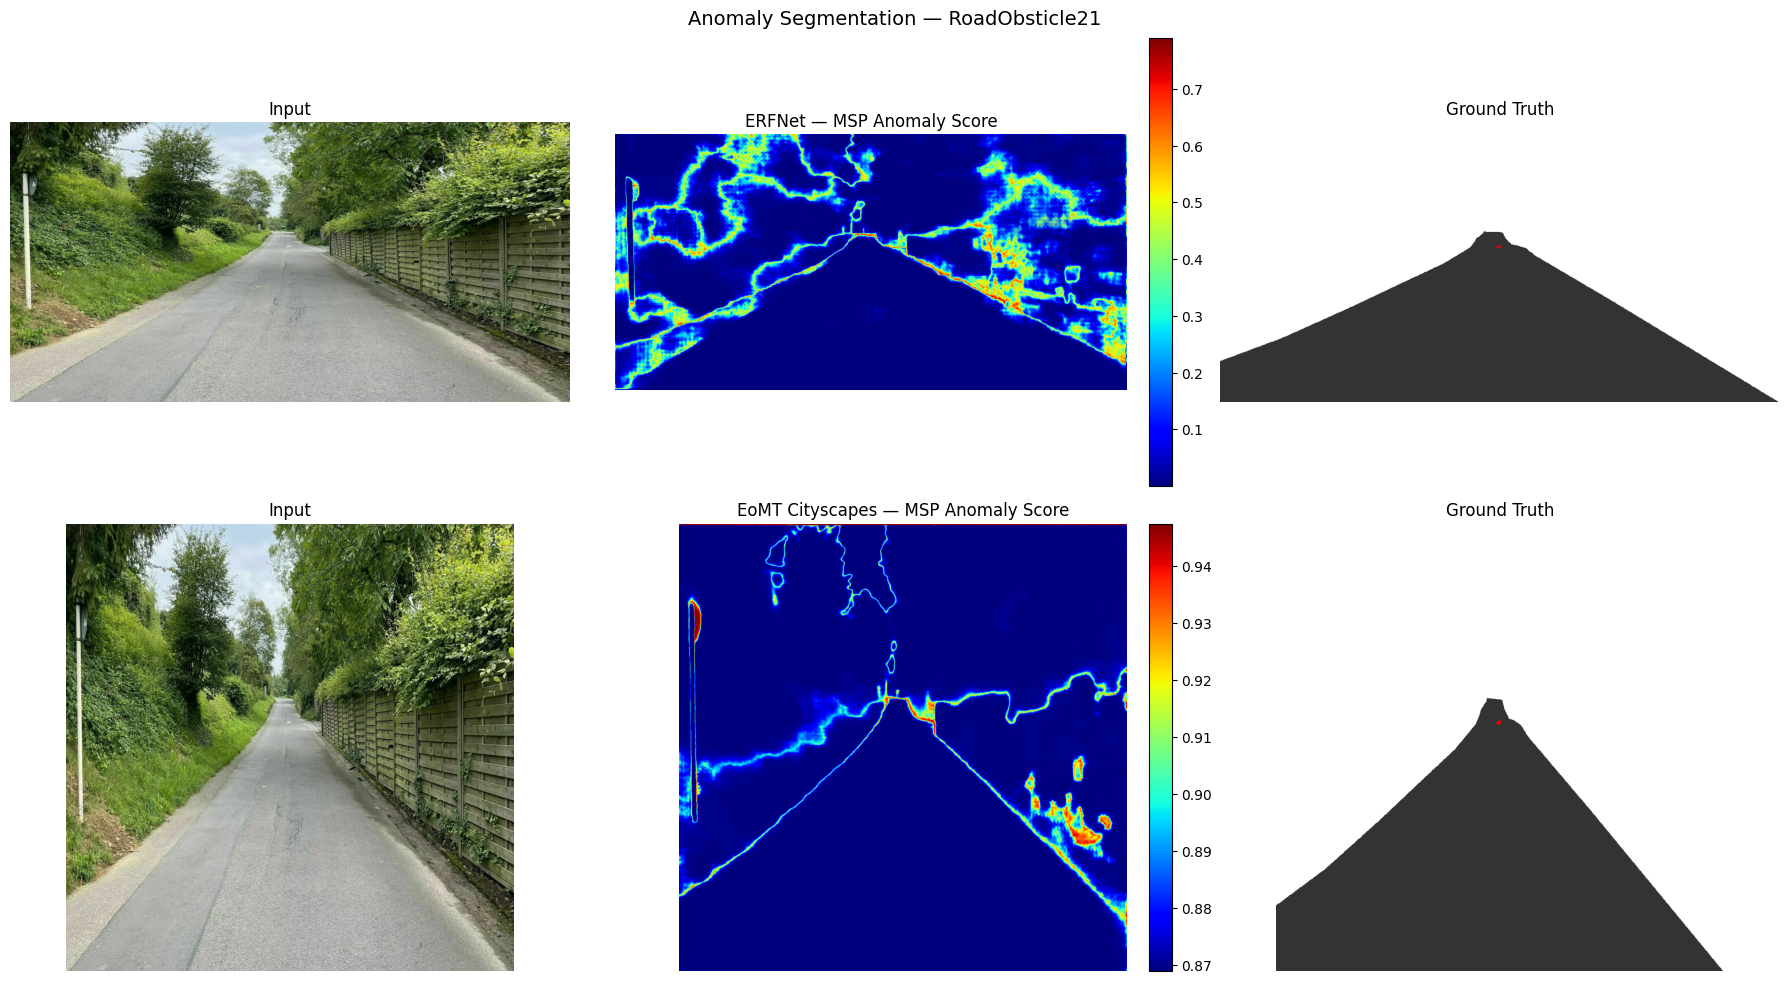

In [5]:
# Find sample images
sample_imgs = sorted(glob.glob(os.path.join(DATASETS_ANOMALY_DIR, DEMO_DATASET, 'images', '*.*')))
if not sample_imgs:
    raise FileNotFoundError(f'No images found in {DATASETS_ANOMALY_DIR}/{DEMO_DATASET}/images')
sample_path = sample_imgs[0]
print(f'Demo image: {os.path.basename(sample_path)}')

# Ground-truth path (webp → png for RoadObsticle21)
gt_path = sample_path.replace('images', 'labels_masks')
for old_ext in ['.webp', '.jpg']:
    gt_path = gt_path.replace(old_ext, '.png')

img_pil = Image.open(sample_path).convert('RGB')

# ERFNet anomaly score
img_erf = transform_erf(img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    out_erf = model_erf(img_erf)
probs_erf = F.softmax(out_erf, dim=1).squeeze(0).cpu().numpy()
msp_erf = 1.0 - np.max(probs_erf, axis=0)
ood_gts_erf, _ = maskGt(gt_path, gt_transform_erf)

# EoMT anomaly score
img_eomt = transform_eomt(img_pil).to(device)
logits_cs = eomt_inference.get_pixel_logits(model_cs, img_eomt, IMG_SIZE_EOMT, device)
probs_cs = F.softmax(logits_cs, dim=0).cpu().numpy()
msp_eomt = 1.0 - np.max(probs_cs, axis=0)
ood_gts_eomt, _ = maskGt(gt_path, gt_transform_eomt)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
show_anomaly_row(axes[0],
                    img_pil.resize((IMG_SIZE_ERF[1], IMG_SIZE_ERF[0])),
                    msp_erf, ood_gts_erf, 'ERFNet')
show_anomaly_row(axes[1],
                    img_pil.resize((IMG_SIZE_EOMT[1], IMG_SIZE_EOMT[0])),
                    msp_eomt, ood_gts_eomt, 'EoMT Cityscapes')
plt.suptitle(f'Anomaly Segmentation — {DEMO_DATASET}', fontsize=14)
plt.tight_layout()
plt.show()
    

## 2. Model Comparison

Runs `eval/evalAnomaly.py` and `eval/evalAnomalyForEomt.py` for every configured model and dataset
combination, then collects the results into `results_anomaly/comparison.csv`.

In [10]:
import subprocess

cmd = [
    'python', os.path.join(REPO_DIR, 'eval/run_eval_anomaly.py'),
    '--datasets-dir', DATASETS_ANOMALY_DIR,
    '--datasets', *DATASETS,
    '--erfnet-weights', W_ERFNET,
    '--output-csv', os.path.join(REPO_DIR, 'results_anomaly/comparison.csv'),
]

if EOMT_MODELS:
    for wc in EOMT_MODELS:
        cmd += ['--eomt-models', wc]

print('Command:', ' '.join(cmd))
print('Running evaluation ... ')
subprocess.run(cmd, check=True)

Command: python /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/eval/run_eval_anomaly.py --datasets-dir /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/datasets/Validation_Dataset --datasets RoadObsticle21 --erfnet-weights /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/erfnet_pretrained.pth --output-csv /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/results_anomaly/comparison.csv --eomt-models /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_cityscapes.bin:/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml --eomt-models /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_coco.bin:/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml --eomt-models /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_coco_finetuned.ckpt:/Users/tim

/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/.venv/lib/python3.13/site-packages/ood_metrics/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Loading model: /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/erfnet.py
Loading weights: /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/erfnet_pretrained.pth
Model and weights loaded successfully
AUPRC score: 2.709975023125903
FPR@TPR95: 65.22307632752157
AUPRC score: 4.626568310490421
FPR@TPR95: 48.443441222061765
AUPRC score: 3.0444042879444986
FPR@TPR95: 65.91168984088289

[run] evalAnomalyForEomt.py --input /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/datasets/Validation_Dataset/RoadObsticle21/images/*.* --loadDataset RoadObsticle21 ...


/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/.venv/lib/python3.13/site-packages/ood_metrics/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Loading checkpoint from /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_coco_finetuned.ckpt with weights_only=True
Loaded weights from /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_coco_finetuned.ckpt

Comparison saved to: /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/results_anomaly/comparison.csv
Model               | Dataset        | Method     | AUPRC | FPR@TPR95
---------------------------------------------------------------------
eomt_cityscapes     | RoadObsticle21 | MSP        | 90.15 | 0.55     
eomt_cityscapes     | RoadObsticle21 | MaxLogit   | 90.09 | 0.58     
eomt_cityscapes     | RoadObsticle21 | MaxEntropy | 90.06 | 0.67     
eomt_cityscapes     | RoadObsticle21 | RbA        | 87.09 | 99.95    
eomt_coco_finetuned | RoadObsticle21 | MSP        | 89.57 | 0.45     
eomt_coco_finetuned | RoadObsticle21 | MaxLogit   | 89.53 | 0.43     
eomt_coco_finetuned | RoadObsticle21 | MaxEntropy | 89.39 | 0.39     
e

CompletedProcess(args=['python', '/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/eval/run_eval_anomaly.py', '--datasets-dir', '/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/datasets/Validation_Dataset', '--datasets', 'RoadObsticle21', '--erfnet-weights', '/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/erfnet_pretrained.pth', '--output-csv', '/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/results_anomaly/comparison.csv', '--eomt-models', '/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_cityscapes.bin:/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml', '--eomt-models', '/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/weights/eomt_coco.bin:/Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml', '--eomt-models', '/Users/timon/polito/ai/MaskArchitectureAnoma

## 3. Temperature Scaling Analysis

Loads pre-saved logits (written by `evalAnomalyForEomt.py`) and evaluates AUPRC and FPR@TPR95
for a range of temperature values.

Logits are saved under `logits/<dataset>/<model_name>/logits_<img>.pt` by the eval script.
Run Section 2 first to generate them.

In [8]:
import csv

TEMPERATURES = [0.5, 0.75, 1.0, 1.1, 1.5]

os.makedirs(os.path.join(REPO_DIR, 'results_anomaly'), exist_ok=True)
csv_path = os.path.join(REPO_DIR, 'results_anomaly', 'results_temperature_scaling.csv')

# Build (model_name, dataset) pairs from EOMT_MODELS x DATASETS
eomt_pairs = []
for wc in EOMT_MODELS:
    w = wc.split(':')[0]
    model_name = os.path.basename(w).split('.')[0]
    for ds in DATASETS:
        eomt_pairs.append((model_name, ds))

temp_results = []

for model_name, ds_name in eomt_pairs:
    logits_dir = os.path.join(REPO_DIR, 'logits', ds_name, model_name)
    if not os.path.isdir(logits_dir):
        print(f'No logits found for {model_name} / {ds_name}. Run Section 2 to generate them.')
        continue

    logit_files = sorted(f for f in os.listdir(logits_dir) if f.endswith('.pt'))
    if not logit_files:
        print(f'Logits directory is empty: {logits_dir}')
        continue

    msp_per_temp = {t: [] for t in TEMPERATURES}
    ood_gts_list = []

    for fname in logit_files:
        logit = torch.load(os.path.join(logits_dir, fname), map_location='cpu')

        for t in TEMPERATURES:
            prob = F.softmax(logit / t, dim=0)
            msp = 1.0 - np.max(prob.cpu().numpy(), axis=0)
            msp_per_temp[t].append(msp)

        # Ground-truth path: logits_<stem>.pt  ->  labels_masks/<stem>.png
        stem = fname.replace('logits_', '').replace('.pt', '')
        gt_path = os.path.join(DATASETS_ANOMALY_DIR, ds_name, 'labels_masks', stem + '.png')
        ood_gts, _ = maskGt(gt_path, gt_transform_eomt)
        if ood_gts is not None:
            ood_gts_list.append(ood_gts)
        else:
            for t in TEMPERATURES:
                msp_per_temp[t].pop()

    if not ood_gts_list:
        print(f'No valid GT found for {model_name} / {ds_name}')
        continue

    ood_arr = np.array(ood_gts_list)
    ood_mask = (ood_arr == 1)
    ind_mask = (ood_arr == 0)

    for t in TEMPERATURES:
        scores = np.array(msp_per_temp[t])
        ood_out = scores[ood_mask]
        ind_out = scores[ind_mask]
        val_out   = np.concatenate((ind_out, ood_out))
        val_label = np.concatenate((np.zeros(len(ind_out)), np.ones(len(ood_out))))

        if len(np.unique(val_label)) < 2:
            print(f'[{model_name} | {ds_name} | T={t}] No anomaly samples — skipping')
            continue

        auprc = average_precision_score(val_label, val_out)
        fpr95 = fpr_at_95_tpr(val_out, val_label)
        row = {
            'Model': model_name, 'Dataset': ds_name,
            'Temperature': t, 'AUPRC': round(auprc * 100, 2), 'FPR@TPR95': round(fpr95 * 100, 2),
        }
        temp_results.append(row)
        print(f'[{model_name} | {ds_name} | T={t:.2f}]  AUPRC={auprc*100:.2f}%  FPR95={fpr95*100:.2f}%')

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['Model', 'Dataset', 'Temperature', 'AUPRC', 'FPR@TPR95'])
    writer.writeheader()
    writer.writerows(temp_results)

print(f'\nSaved: {csv_path}')

[eomt_cityscapes | RoadObsticle21 | T=0.50]  AUPRC=90.14%  FPR95=0.55%
[eomt_cityscapes | RoadObsticle21 | T=0.75]  AUPRC=90.14%  FPR95=0.55%
[eomt_cityscapes | RoadObsticle21 | T=1.00]  AUPRC=90.15%  FPR95=0.55%
[eomt_cityscapes | RoadObsticle21 | T=1.10]  AUPRC=90.15%  FPR95=0.55%
[eomt_cityscapes | RoadObsticle21 | T=1.50]  AUPRC=90.15%  FPR95=0.55%
No logits found for eomt_coco / RoadObsticle21. Run Section 2 to generate them.
[eomt_coco_finetuned | RoadObsticle21 | T=0.50]  AUPRC=89.55%  FPR95=0.45%
[eomt_coco_finetuned | RoadObsticle21 | T=0.75]  AUPRC=89.56%  FPR95=0.45%
[eomt_coco_finetuned | RoadObsticle21 | T=1.00]  AUPRC=89.57%  FPR95=0.45%
[eomt_coco_finetuned | RoadObsticle21 | T=1.10]  AUPRC=89.57%  FPR95=0.45%
[eomt_coco_finetuned | RoadObsticle21 | T=1.50]  AUPRC=89.58%  FPR95=0.45%

Saved: /Users/timon/polito/ai/MaskArchitectureAnomaly_CourseProject/results_anomaly/results_temperature_scaling.csv


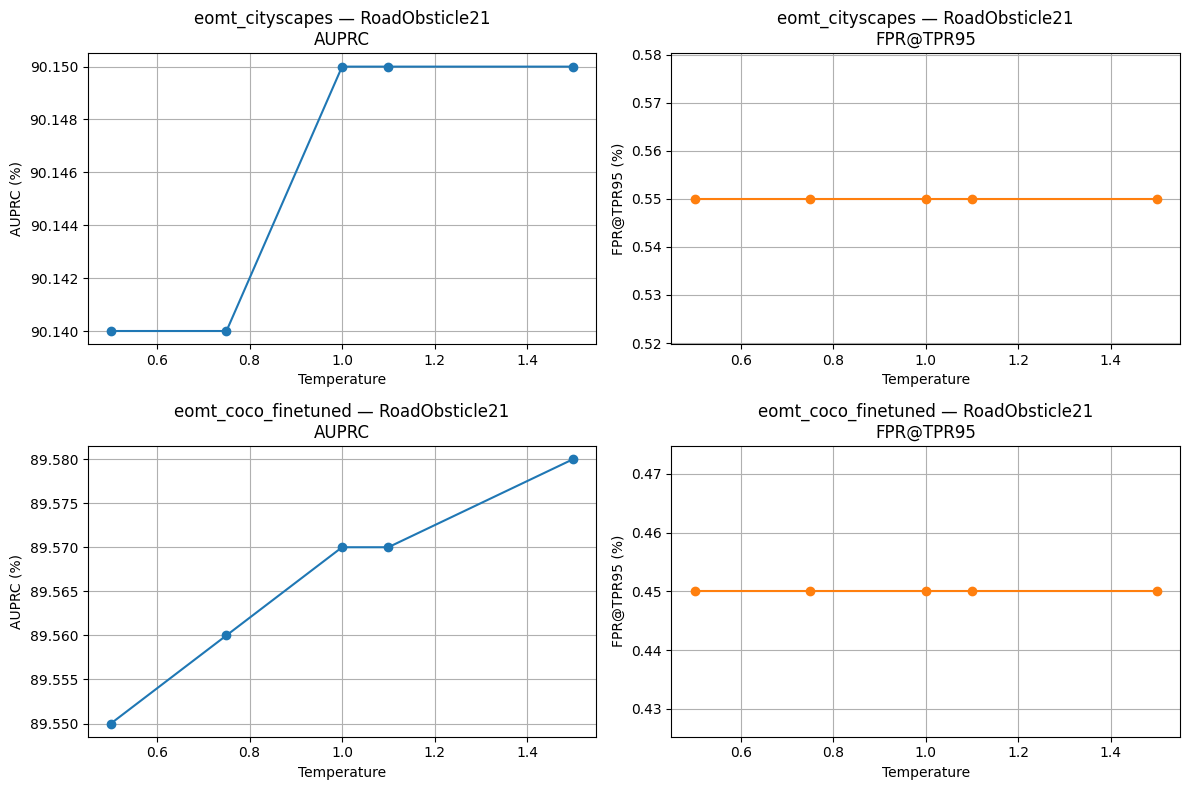

In [9]:
if not temp_results:
    print('No temperature scaling results to plot. Run the cell above first.')
else:
    from collections import defaultdict
    by_key = defaultdict(list)  # (model, dataset) -> list of (temp, auprc, fpr95)
    for r in temp_results:
        by_key[(r['Model'], r['Dataset'])].append(
            (r['Temperature'], r['AUPRC'], r['FPR@TPR95'])
        )

    n = len(by_key)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
    for row, ((model, ds), vals) in enumerate(by_key.items()):
        vals_sorted = sorted(vals, key=lambda x: x[0])
        temps  = [v[0] for v in vals_sorted]
        auprcs = [v[1] for v in vals_sorted]
        fprs   = [v[2] for v in vals_sorted]

        axes[row][0].plot(temps, auprcs, marker='o')
        axes[row][0].set_title(f'{model} — {ds}\nAUPRC')
        axes[row][0].set_xlabel('Temperature'); axes[row][0].set_ylabel('AUPRC (%)')
        axes[row][0].grid(True)

        axes[row][1].plot(temps, fprs, marker='o', color='tab:orange')
        axes[row][1].set_title(f'{model} — {ds}\nFPR@TPR95')
        axes[row][1].set_xlabel('Temperature'); axes[row][1].set_ylabel('FPR@TPR95 (%)')
        axes[row][1].grid(True)

    plt.tight_layout()
    plt.show()